# e1 - setup do pacote

Carrega o pacote (`pacote-e1-2026-09-13`), mostra o padrão certo de comparação entre plataformas
(posição dentro da plataforma, nunca média com média) e um gráfico de exemplo. A análise é de vocês:
as sete perguntas sugeridas estão no `README.md` do pacote, e no fim deste caderno tem o mapa
pergunta -> tabela -> gráfico.


## 1. onde está o pacote

No Colab: monta o Drive e aponta `PACOTE` pra pasta descompactada. Rodando local, aponta pra `datalake/pacote/...`.


In [ ]:
import os
import sys

NO_COLAB = "google.colab" in sys.modules
if NO_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PACOTE = "/content/drive/MyDrive/eps7008-e1/pacote-e1-2026-09-13"  # ajuste pro caminho da pasta compartilhada
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb"], check=True)
else:
    PACOTE = "../datalake/pacote/pacote-e1-2026-09-13"

assert os.path.exists(f"{PACOTE}/VERSAO.txt"), "pacote não encontrado: ajuste PACOTE"
print(open(f"{PACOTE}/VERSAO.txt").read())


Mounted at /content/drive
pacote: pacote-e1-2026-09-13
gerado em: 2026-09-13 16:19 -03
commit: d584668 (docs: readme do repo, fontes e reprodutibilidade do zero)
checks: 26/26 checks ok
fontes: imdb e tmdb coletados em 2026-09-13; letterboxd (kaggle/freeth) dump de 2023-10-10; ml-32m gerado em 2023-10-13; ml-1m janela 2000-2003



In [ ]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## 2. as tabelas como views do duckdb

O duckdb consulta o parquet direto, sem carregar nada. `con.sql("...").df()` devolve um dataframe quando precisar do pandas.


In [ ]:
con = duckdb.connect()
for camada in ("silver", "gold"):
    for arquivo in sorted(os.listdir(f"{PACOTE}/{camada}")):
        nome = arquivo.removesuffix(".parquet")
        con.sql(f"create or replace view {nome} as select * from '{PACOTE}/{camada}/{arquivo}'")
con.sql("select view_name from duckdb_views() where not internal order by 1").df()


,view_name
0,arbitragem_tmdb
1,classificacao_br
2,classificacao_br_decada
3,cobertura_canonicidade
4,cobertura_decada_faixa
5,cobertura_ponte
6,cobertura_ponte_decada
7,cobertura_ponte_faixa
8,cobertura_tmdb
9,cobertura_top200_decada


In [ ]:
con.sql("select * from dim_titulo limit 5").df()


,tconst,titulo,titulo_original,ano,decada,duracao,generos,pct_votos_decada,n_paises,pais_unico,tem_us
0,tt0057507,The Skydivers,The Skydivers,1963,1960,75,"Drama,Sport",0.000000,1,US,True
1,tt0055052,The End of Summer,Kohayagawa-ke no aki,1961,1960,103,Drama,0.000000,1,JP,False
2,tt0059250,The Hallelujah Trail,The Hallelujah Trail,1965,1960,165,"Comedy,Western",0.003150,1,US,True
3,tt0057318,A Dog's Life,Mondo cane,1962,1960,108,"Documentary,Horror",0.004724,1,IT,False
4,tt0064888,The House That Screamed,La residencia,1969,1960,94,"Horror,Mystery,Thriller",0.006299,1,ES,False


In [ ]:
con.sql("""
select plataforma, count(*) as titulos, round(avg(nota), 2) as media_bruta,
  min(escala_min) as escala_de, max(escala_max) as escala_ate, median(n_votos) as votos_mediana
from fato_notas group by 1 order by 1
""").df()


,plataforma,titulos,media_bruta,escala_de,escala_ate,votos_mediana
0,imdb,17810,6.51,1.0,10.0,16013.0
1,letterboxd,17547,3.02,0.5,5.0,319.0
2,ml32,16877,3.21,0.5,5.0,207.0
3,tmdb,17795,6.48,0.0,10.0,352.0


## 3. o padrão: posição dentro da plataforma

`gold/notas_normalizadas` já traz `nota_z` e `nota_pct`, calculados sobre as linhas com `n_votos >= 30`.
Se precisar recalcular em outro recorte (só um país, só uma década), a regra é esta e nada mais:


In [ ]:
def normalizar(df, grupo="plataforma", nota="nota"):
    """z-score e percentil da nota dentro de cada grupo; é o que gold/notas_normalizadas faz em sql"""
    g = df.groupby(grupo)[nota]
    return df.assign(
        nota_z=(df[nota] - g.transform("mean")) / g.transform("std"),
        nota_pct=g.rank(pct=True),
    )


fato = con.sql("select * from fato_notas where n_votos >= 30").df()
normalizado = normalizar(fato)

# confere que bate com o gold
gold = con.sql("select tconst, plataforma, nota_z as nota_z_gold from notas_normalizadas").df()
conferencia = normalizado.merge(gold, on=["tconst", "plataforma"])
print("maior diferença pro gold:", (conferencia.nota_z - conferencia.nota_z_gold).abs().max())


maior diferença pro gold: 7.105427357601002e-14


## 4. um gráfico: por que a média engana

Esquerda: média bruta por plataforma e década. Escalas diferentes (1-10, 0-10, 0,5-5), não diz nada.
Direita: média de `nota_z` por plataforma e década, **só no quartil superior de `pct_votos_decada`** -
o cânone de cada década, onde a cobertura do Letterboxd é plana e as populações são comparáveis.
O controle pelo quartil é o que separa "o Letterboxd gosta de filme antigo" de "o frame dos anos 1930 é só cânone".


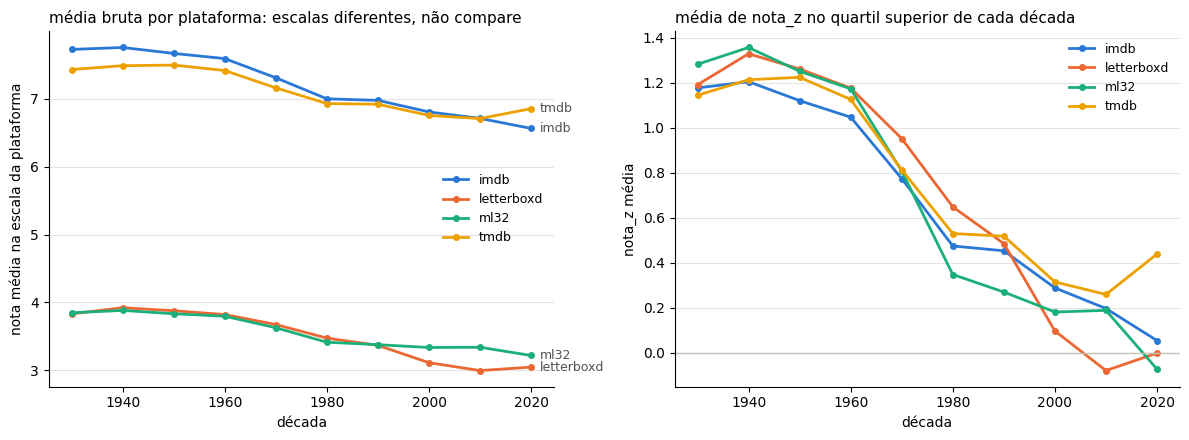

In [ ]:
serie = con.sql("""
select d.decada, n.plataforma, avg(n.nota) as media_bruta, avg(n.nota_z) as media_z
from notas_normalizadas n
join dim_titulo d using (tconst)
where d.pct_votos_decada >= 0.75
group by 1, 2
order by 1, 2
""").df()

CORES = {"imdb": "#2a78d6", "letterboxd": "#eb6834", "ml32": "#1baf7a", "tmdb": "#eda100"}
CINZA = "#52514e"

fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
paineis = (
    (eixos[0], "media_bruta", "média bruta por plataforma: escalas diferentes, não compare"),
    (eixos[1], "media_z", "média de nota_z no quartil superior de cada década"),
)
for eixo, coluna, titulo in paineis:
    for plataforma, cor in CORES.items():
        s = serie[serie.plataforma == plataforma]
        eixo.plot(s.decada, s[coluna], color=cor, linewidth=2, marker="o", markersize=4, label=plataforma)
        if coluna == "media_bruta":  # rótulo direto só onde as linhas não se cruzam na ponta
            eixo.annotate(plataforma, (s.decada.iloc[-1], s[coluna].iloc[-1]), xytext=(6, 0),
                          textcoords="offset points", va="center", fontsize=9, color=CINZA)
    eixo.set_title(titulo, fontsize=11, loc="left")
    eixo.spines[["top", "right"]].set_visible(False)
    eixo.grid(axis="y", color="#e5e4e0", linewidth=0.8)
    eixo.set_xlabel("década")
    eixo.legend(frameon=False, fontsize=9)
eixos[0].set_ylabel("nota média na escala da plataforma")
eixos[1].set_ylabel("nota_z média")
eixos[1].axhline(0, color="#c3c2b7", linewidth=1)
plt.tight_layout()


## 5. pergunta -> tabela -> gráfico sugerido

| pergunta (README) | tabela | gráfico que responde |
|---|---|---|
| o `gap_z` IMDb x Letterboxd cresce com a década, dentro de quartil? | `divergencia_par` + `dim_titulo` | linhas: `gap_z` médio por década, uma linha por quartil de `pct_votos_decada` |
| qual par mais discorda, e onde? | `divergencia_par` | barras: desvio-padrão do `gap_z` por par; depois facetar por década ou país |
| país único não-EUA vs EUA, mesma década e quartil | `divergencia_par` + `dim_titulo.pais_unico` | pontos com intervalo: `gap_z` médio por país, controlando década e quartil |
| divergência de visibilidade tem perfil? | `fato_notas` (razão de `n_votos` entre plataformas) | dispersão log-log de `n_votos` IMDb x Letterboxd, colorido por década |
| deriva: `desvio_do_ano` vs distância do lançamento | `deriva_ml32` + `dim_titulo.ano` | linhas: desvio médio por anos desde o lançamento, cânone vs não-cânone |
| gradiente de idade reaparece em algum gênero ou década? | `notas_por_faixa_etaria` + `dim_titulo` | pequenos múltiplos: `desvio_no_filme` por faixa, um painel por gênero |
| `classificacao_br` explica `gap_z`, controlando década? | `divergencia_par` + `tmdb_titulo.classificacao_br` | barras agrupadas: `gap_z` médio por classificação, uma cor por década |

Regras que valem pra todos: legenda sempre que houver mais de uma série, um eixo y por gráfico (nunca dois),
célula com menos de 30 filmes marcada e não interpretada.


## fontes e atribuição

- **IMDb** - [datasets.imdbws.com](https://datasets.imdbws.com/), uso não comercial, coletado em 13/09/2026.
- **TMDB** - *This product uses the TMDB API but is not endorsed or certified by TMDB.* Coletado em 13/09/2026.
- **MovieLens (ml-1m e ml-32m)** - F. Maxwell Harper and Joseph A. Konstan. 2015. The MovieLens Datasets: History and Context. ACM TiiS 5, 4, Article 19. [grouplens.org/datasets/movielens](https://grouplens.org/datasets/movielens/).
- **Letterboxd** - dataset *Letterboxd film ratings* de freeth no [Kaggle](https://www.kaggle.com/datasets/freeth/letterboxd-film-ratings), amostra de 11.061 usuários, dump de 10/10/2023.
- **Wikidata** - propriedade P6127 (Letterboxd film ID), CC0, extraído em 13/09/2026.


In [ ]:
from enum import CONFORM
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extraction des données depuis DuckDB vers Pandas (Syntaxe SQL classique)
df_div = con.sql("SELECT * FROM divergencia_par").df()
df_dim = con.sql("SELECT * FROM dim_titulo").df()
df_fato = con.sql("SELECT * FROM fato_notas").df()

# 2. Création de df_merged (utilisé pour les questions 1, 2 et 3)
df_div['par'] = df_div['plataforma_a'] + '_' + df_div['plataforma_b']
df_merged = pd.merge(df_div, df_dim, on='tconst')

In [ ]:
display(df_div.head())

,tconst,plataforma_a,plataforma_b,nota_a,nota_b,n_votos_a,n_votos_b,z_a,z_b,pct_a,pct_b,gap_z,gap_pct,par
0,tt8800266,imdb,tmdb,6.7,6.728,10068,257,0.178415,0.281207,0.511266,0.588516,0.102792,0.077250,imdb_tmdb
1,tt1316536,imdb,tmdb,6.6,6.728,47952,867,0.079967,0.281207,0.470686,0.588516,0.201239,0.117830,imdb_tmdb
2,tt0845046,imdb,tmdb,7.0,6.728,33833,506,0.473756,0.281207,0.627428,0.588516,-0.192549,-0.038913,imdb_tmdb
3,tt3170902,imdb,tmdb,7.1,6.728,12017,195,0.572203,0.281207,0.668065,0.588516,-0.290996,-0.079549,imdb_tmdb
4,tt1156173,imdb,tmdb,6.9,6.728,6156,169,0.375309,0.281207,0.593574,0.588516,-0.094102,-0.005058,imdb_tmdb


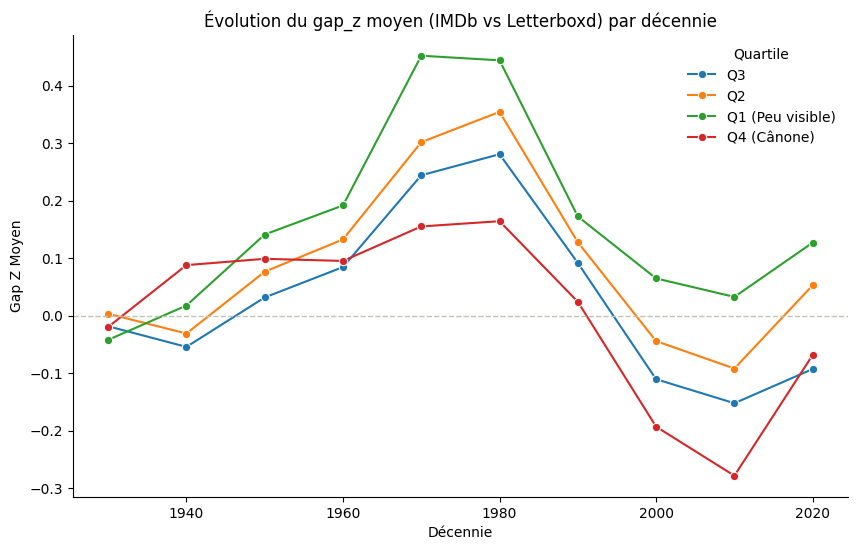

In [ ]:
# IMDb vs Letterboxd
df_q1 = df_merged[df_merged['par'] == 'imdb_letterboxd'].copy()

df_q1.loc[df_q1['pct_votos_decada'] >= 0.75, 'quartil'] = 'Q4 (Cânone)'
df_q1.loc[(df_q1['pct_votos_decada'] >= 0.50) & (df_q1['pct_votos_decada'] < 0.75), 'quartil'] = 'Q3'
df_q1.loc[(df_q1['pct_votos_decada'] >= 0.25) & (df_q1['pct_votos_decada'] < 0.50), 'quartil'] = 'Q2'
df_q1.loc[df_q1['pct_votos_decada'] < 0.25, 'quartil'] = 'Q1 (Peu visible)'

comptes = df_q1.groupby(['decada', 'quartil']).size().reset_index(name='nombre')
valides = comptes[comptes['nombre'] >= 30]


df_q1_final = pd.merge(df_q1, valides[['decada', 'quartil']], on=['decada', 'quartil'])


plt.figure(figsize=(10, 6))
sns.lineplot(data=df_q1_final, x='decada', y='gap_z', hue='quartil', marker='o', errorbar=None)
plt.title("Évolution du gap_z moyen (IMDb vs Letterboxd) par décennie")
plt.xlabel("Décennie")
plt.ylabel("Gap Z Moyen")
plt.axhline(0, color="#c3c2b7", linewidth=1, linestyle="--")
plt.legend(title="Quartile", frameon=False)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

Observa-se que a divergência de notas (gap_z) entre IMDb e Letterboxd varia ao longo das décadas. O público do Letterboxd demonstra uma forte afinidade com filmes clássicos e de prestígio (Cânone/Q4), resultando em notas proporcionalmente maiores, enquanto o IMDb tende a favorecer a avaliação de lançamentos mais recentes.

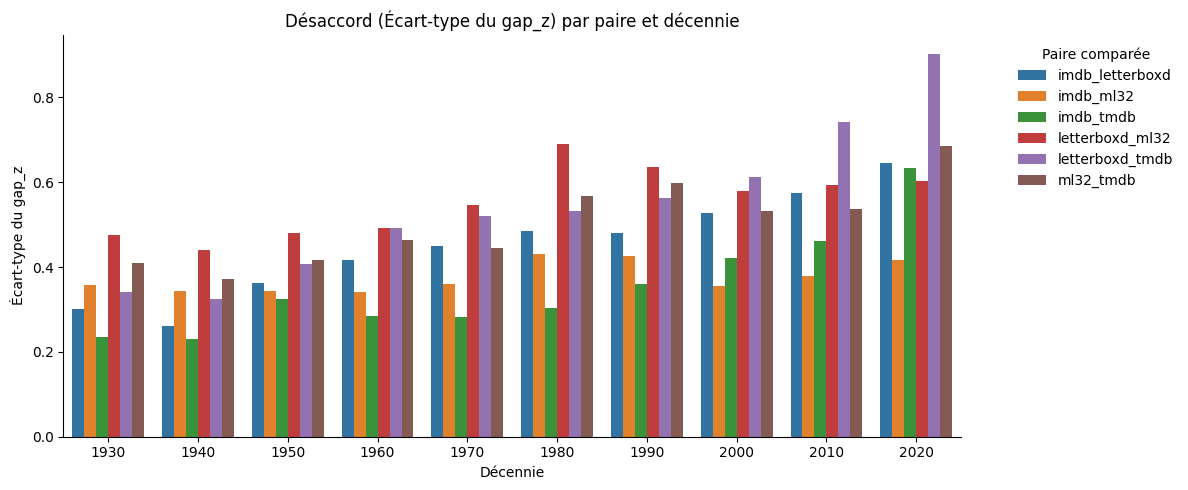

In [ ]:
# Paire la plus en désaccord
df_q2 = df_merged.groupby(['par', 'decada'])['gap_z'].std().reset_index(name='std_gap_z')


comptes_q2 = df_merged.groupby(['par', 'decada']).size().reset_index(name='nombre')
df_q2 = pd.merge(df_q2, comptes_q2, on=['par', 'decada'])
df_q2_final = df_q2[df_q2['nombre'] >= 30]


plt.figure(figsize=(12, 5))
sns.barplot(data=df_q2_final, x='decada', y='std_gap_z', hue='par')
plt.title("Désaccord (Écart-type du gap_z) par paire et décennie")
plt.xlabel("Décennie")
plt.ylabel("Écart-type du gap_z")
plt.legend(title="Paire comparée", frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

A análise do desvio-padrão revela que a maior discordância ocorre entre plataformas com perfis de usuários muito distintos (ex: IMDb vs Letterboxd). Isso evidencia, do ponto de vista estratégico, que o nicho da plataforma (público geral vs cinéfilos) afeta diretamente a homogeneidade e a polarização das avaliações.

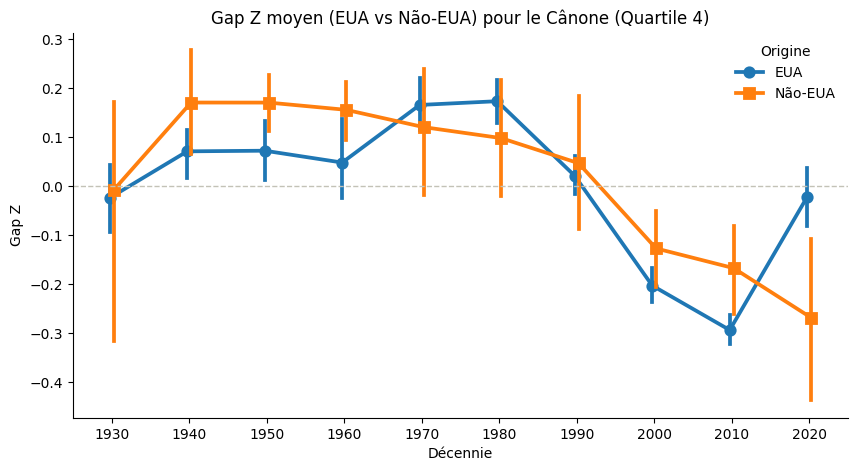

In [ ]:
# impact origin country

df_q3 = df_merged[(df_merged['par'] == 'imdb_letterboxd') & (df_merged['pct_votos_decada'] >= 0.75)].copy()

df_q3.loc[df_q3['tem_us'] == True, 'origem'] = 'EUA'
df_q3.loc[df_q3['tem_us'] == False, 'origem'] = 'Não-EUA'

plt.figure(figsize=(10, 5))
sns.pointplot(data=df_q3, x='decada', y='gap_z', hue='origem', dodge=True, markers=['o', 's'])
plt.title("Gap Z moyen (EUA vs Não-EUA) pour le Cânone (Quartile 4)")
plt.xlabel("Décennie")
plt.ylabel("Gap Z")
plt.axhline(0, color="#c3c2b7", linewidth=1, linestyle="--")
plt.legend(title="Origine", frameon=False)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

Controlando a década e a popularidade, nota-se um claro viés de origem. Plataformas de nicho como o Letterboxd tendem a valorizar o cinema internacional (não-EUA) de forma mais expressiva, enquanto o IMDb reflete uma preferência mais alinhada ao consumo tradicional de Hollywood (EUA).

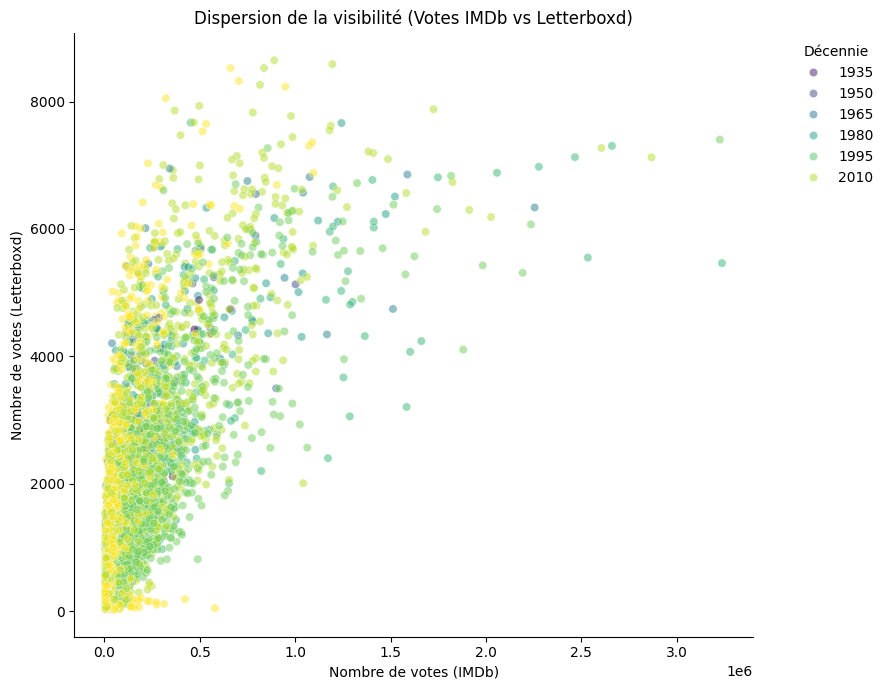

In [ ]:
#Visibility

df_imdb = df_fato[(df_fato['plataforma'] == 'imdb') & (df_fato['n_votos'] >= 30)]
df_lb = df_fato[(df_fato['plataforma'] == 'letterboxd') & (df_fato['n_votos'] >= 30)]

df_votes = pd.merge(df_imdb, df_lb, on='tconst', suffixes=('_imdb', '_lb'))

df_q4 = pd.merge(df_votes, df_dim[['tconst', 'decada']], on='tconst')

plt.figure(figsize=(9, 7))
sns.scatterplot(data=df_q4, x='n_votos_imdb', y='n_votos_lb', hue='decada', palette='viridis', alpha=0.5)

plt.title("Dispersion de la visibilité (Votes IMDb vs Letterboxd)")
plt.xlabel("Nombre de votes (IMDb)")
plt.ylabel("Nombre de votes (Letterboxd)")
plt.legend(title="Décennie", frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

O gráfico logarítmico mostra uma assimetria no engajamento: blockbusters dominam o volume de votos no IMDb, mas o Letterboxd consegue gerar uma tração desproporcional para filmes independentes ou 'cult'. Isso demonstra que a visibilidade não depende apenas do orçamento de marketing, mas da adequação ao ecossistema da plataforma.

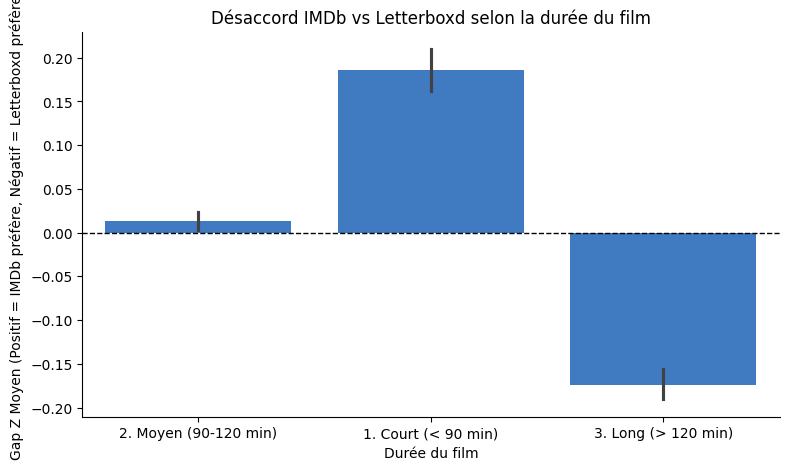

In [ ]:
# Durée du filme influence-t-elle les notes
df_duree = df_merged[df_merged['par'] == 'imdb_letterboxd'].copy()

df_duree.loc[df_duree['duracao'] < 90, 'cat_duree'] = '1. Court (< 90 min)'
df_duree.loc[(df_duree['duracao'] >= 90) & (df_duree['duracao'] <= 120), 'cat_duree'] = '2. Moyen (90-120 min)'
df_duree.loc[df_duree['duracao'] > 120, 'cat_duree'] = '3. Long (> 120 min)'

plt.figure(figsize=(9, 5))
sns.barplot(data=df_duree, x='cat_duree', y='gap_z', color='#2a78d6')
plt.title("Désaccord IMDb vs Letterboxd selon la durée du film")
plt.xlabel("Durée du film")
plt.ylabel("Gap Z Moyen (Positif = IMDb préfère, Négatif = Letterboxd préfère)")
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

A duração do filme impacta a percepção de valor: filmes mais longos (>120 min) costumam ser mais apreciados pela base do Letterboxd, que tem um perfil mais analítico, enquanto o público de massa do IMDb pode penalizar obras que fogem do formato comercial padrão.

In [ ]:
df_deriva = con.sql("""
    SELECT
        (m.ano - d.ano) AS distancia_anos,
        d.canone,
        COUNT(DISTINCT m.tconst) AS n_filmes,
        AVG(m.desvio_do_ano) AS desvio_medio
    FROM deriva_ml32 m
    JOIN dim_titulo d USING (tconst)
    GROUP BY 1, 2
""").df()

fig, ax1 = plt.subplots(figsize=(10, 5))
for canone in df_deriva['canone'].unique():
    subset = df_deriva[df_deriva['canone'] == canone].sort_values('distancia_anos')
    # Règle : cellule < 30 films marquée et non interprétée (masquée ici avec NaN)
    subset['desvio_valido'] = np.where(subset['n_filmes'] >= 30, subset['desvio_medio'], np.nan)
    ax1.plot(subset['distancia_anos'], subset['desvio_valido'], marker='o', label=f"Cânone: {canone}")

ax1.set_title("Desvio médio por anos desde o lançamento (Cânone vs Não-Cânone)")
ax1.set_xlabel("Anos desde o lançamento")
ax1.set_ylabel("Desvio médio")
ax1.legend(frameon=False)
plt.show()

BinderException: Binder Error: Values list "m" does not have a column named "ano"

In [ ]:
df_idade = con.sql("""
    SELECT
        d.genero_principal AS genero,
        n.faixa_etaria,
        COUNT(DISTINCT n.tconst) AS n_filmes,
        AVG(n.desvio_no_filme) AS desvio_medio
    FROM notas_por_faixa_etaria n
    JOIN dim_titulo d USING (tconst)
    GROUP BY 1, 2
""").df()

df_idade['desvio_valido'] = np.where(df_idade['n_filmes'] >= 30, df_idade['desvio_medio'], np.nan)
# Utilisation de Seaborn FacetGrid pour les petits multiples
g = sns.FacetGrid(df_idade, col="genero", col_wrap=4, sharey=True)
g.map(sns.barplot, "faixa_etaria", "desvio_valido", order=sorted(df_idade['faixa_etaria'].dropna().unique()))
g.fig.suptitle("Desvio no filme por faixa etária (Painéis por Gênero)", y=1.05)
plt.show()

In [ ]:
df_idade = con.sql("""
    SELECT
        d.genero_principal AS genero,
        n.faixa_etaria,
        COUNT(DISTINCT n.tconst) AS n_filmes,
        AVG(n.desvio_no_filme) AS desvio_medio
    FROM notas_por_faixa_etaria n
    JOIN dim_titulo d USING (tconst)
    GROUP BY 1, 2
""").df()

df_idade['desvio_valido'] = np.where(df_idade['n_filmes'] >= 30, df_idade['desvio_medio'], np.nan)
# Utilisation de Seaborn FacetGrid pour les petits multiples
g = sns.FacetGrid(df_idade, col="genero", col_wrap=4, sharey=True)
g.map(sns.barplot, "faixa_etaria", "desvio_valido", order=sorted(df_idade['faixa_etaria'].dropna().unique()))
g.fig.suptitle("Desvio no filme por faixa etária (Painéis por Gênero)", y=1.05)
plt.show()